# Notebook 07 — Evaluación Longitudinal (Mes 0 → Mes 4)

**Estrategia:** Entrenamiento-único en Mes 0 → Evaluación mes a mes sin reentrenar.

El objetivo de este notebook es responder a la pregunta central de la tesis:
> *¿Cuánto se degrada la precisión de los modelos entrenados en el Mes 0 cuando se les presentan señales EMG de los meses posteriores?*

**Flujo:**
1. Cargar datos `.mat` de los 5 usuarios filtrados (Mes 0 a Mes 4)
2. Extraer features (72 = 9 features × 8 canales) para cada repetición
3. Entrenar kNN, SVM y ANN con los datos del **Mes 0** (usando hiperparámetros óptimos ya conocidos)
4. Evaluar los modelos sobre los datos de los **Mes 1–4** sin reentrenar
5. Graficar la degradación longitudinal del accuracy

In [1]:
# ── Montaje de Drive y configuración de rutas (Colab) ─────────────────────────
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import glob
    paths = glob.glob('/content/drive/**/emg-classification-knn-svm-ann', recursive=True)
    pc = [p for p in paths if 'Othercomputers' in p or 'Ordenadores' in p]
    PROJECT_PATH = sorted(pc or paths, key=len)[0] if paths else '/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
except:
    if 'notebooks' in os.getcwd(): os.chdir('..')
    sys.path.insert(0, os.getcwd())

print('CWD:', os.getcwd())

Mounted at /content/drive
CWD: /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from src.config import Config
from src.mat_loader import load_all_sessions, GESTURES
from src.feature_extraction import extract_features

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: []


In [3]:
# ── Parámetros globales ────────────────────────────────────────────────────────
LONGITUDINAL_DIR = Config.BASE_DIR / 'data' / 'longitudinal' / 'usuarios'
MODELS_DIR       = Config.PROCESSED_DIR / 'models' / 'longitudinal'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

GESTURES_5 = ['fist', 'open', 'pinch', 'waveIn', 'waveOut']   # sin relax
CLASS_NAMES = GESTURES_5
N_CLASSES   = len(GESTURES_5)

print(f'Directorio longitudinal: {LONGITUDINAL_DIR}')
print(f'Gestos: {GESTURES_5}')

Directorio longitudinal: /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann/data/longitudinal/usuarios
Gestos: ['fist', 'open', 'pinch', 'waveIn', 'waveOut']


## 1. Carga de todos los datos longitudinales

In [4]:
# Carga todos los meses disponibles (Mes0–Mes4)
# sessions['Mes0']['user4'] → (X_raw [N_reps, 1002, 8], y [N_reps])
sessions = load_all_sessions(LONGITUDINAL_DIR, gestures=GESTURES_5)
print(f'\nMeses cargados: {list(sessions.keys())}')

# Verificar usuarios por mes
for mes, users in sessions.items():
    total_reps = sum(len(v[1]) for v in users.values())
    print(f'  {mes}: {len(users)} usuarios, {total_reps} repeticiones totales')


📅 Cargando Mes0...
  Cargado user12: 250 repeticiones, 988 muestras × 8 canales
  Cargado user14: 250 repeticiones, 988 muestras × 8 canales
  Cargado user21: 250 repeticiones, 988 muestras × 8 canales
  Cargado user23: 250 repeticiones, 988 muestras × 8 canales
  Cargado user24: 250 repeticiones, 990 muestras × 8 canales
  Cargado user26: 250 repeticiones, 988 muestras × 8 canales
  Cargado user35: 250 repeticiones, 988 muestras × 8 canales
  Cargado user37: 250 repeticiones, 988 muestras × 8 canales
  Cargado user4: 250 repeticiones, 988 muestras × 8 canales
  Cargado user40: 250 repeticiones, 988 muestras × 8 canales
  Cargado user42: 250 repeticiones, 988 muestras × 8 canales
  Cargado user43: 250 repeticiones, 988 muestras × 8 canales
  Cargado user49: 250 repeticiones, 988 muestras × 8 canales
  Cargado user5: 250 repeticiones, 984 muestras × 8 canales
  Cargado user55: 250 repeticiones, 988 muestras × 8 canales
  Cargado user57: 250 repeticiones, 988 muestras × 8 canales
  Carg

Traceback (most recent call last):
  File "/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann/src/mat_loader.py", line 37, in _load_gesture_mat
    emg_raw = gesture_data[i]['emg']
              ~~~~~~~~~~~~~~~^^^^^^^
IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


  Cargado user14: 200 repeticiones, 990 muestras × 8 canales
  Cargado user21: 250 repeticiones, 988 muestras × 8 canales
  Cargado user23: 250 repeticiones, 986 muestras × 8 canales
  Cargado user24: 250 repeticiones, 988 muestras × 8 canales
  Cargado user26: 250 repeticiones, 986 muestras × 8 canales
  Cargado user35: 250 repeticiones, 988 muestras × 8 canales
  Cargado user37: 250 repeticiones, 988 muestras × 8 canales
  Cargado user4: 250 repeticiones, 990 muestras × 8 canales
  Cargado user40: 250 repeticiones, 974 muestras × 8 canales
  Cargado user42: 250 repeticiones, 980 muestras × 8 canales
  Cargado user43: 250 repeticiones, 988 muestras × 8 canales
  Cargado user49: 250 repeticiones, 986 muestras × 8 canales
  Cargado user5: 250 repeticiones, 986 muestras × 8 canales
  Cargado user55: 250 repeticiones, 988 muestras × 8 canales
  Cargado user57: 250 repeticiones, 988 muestras × 8 canales
  Cargado user6: 250 repeticiones, 986 muestras × 8 canales
  Cargado user8: 250 repeti

## 2. Extracción de features

Cada repetición EMG (1002 × 8) se usa como **una sola ventana** → vector de 72 features.

In [5]:
def build_features_from_sessions(sessions_dict, months_to_use=None):
    """
    Extrae features de todos los meses y usuarios.

    Returns:
        dict {mes_name: (X [N, 72], y [N])}
    """
    if months_to_use is None:
        months_to_use = list(sessions_dict.keys())

    result = {}
    for mes in months_to_use:
        if mes not in sessions_dict:
            print(f'WARN: {mes} no encontrado')
            continue

        X_list, y_list = [], []
        for user_id, (X_raw, y_raw) in sessions_dict[mes].items():
            for i in range(len(y_raw)):
                emg_window = X_raw[i]           # (1002, 8)
                feat = extract_features(emg_window)   # (72,)
                X_list.append(feat)
                y_list.append(y_raw[i])

        result[mes] = (np.array(X_list), np.array(y_list))
        print(f'{mes}: X={result[mes][0].shape}, clases={np.unique(result[mes][1]).tolist()}')

    return result

print('Extrayendo features...')
features_by_month = build_features_from_sessions(sessions)
print('\nListo.')

Extrayendo features...
Mes0: X=(4750, 72), clases=['fist', 'open', 'pinch', 'waveIn', 'waveOut']
Mes1: X=(4750, 72), clases=['fist', 'open', 'pinch', 'waveIn', 'waveOut']
Mes2: X=(4700, 72), clases=['fist', 'open', 'pinch', 'waveIn', 'waveOut']
Mes3: X=(4750, 72), clases=['fist', 'open', 'pinch', 'waveIn', 'waveOut']
Mes4: X=(4750, 72), clases=['fist', 'open', 'pinch', 'waveIn', 'waveOut']
Mes5: X=(4750, 72), clases=['fist', 'open', 'pinch', 'waveIn', 'waveOut']
Mes6: X=(4750, 72), clases=['fist', 'open', 'pinch', 'waveIn', 'waveOut']

Listo.


## 3. Entrenamiento en Mes 0

Se usan los **hiperparámetros óptimos ya conocidos** del GridSearchCV previo.
No se repite la búsqueda → entrenamiento en ~1 minuto.

In [6]:
X_mes0, y_mes0 = features_by_month['Mes0']

# Encodificar etiquetas
le = LabelEncoder()
le.fit(CLASS_NAMES)
y_mes0_enc = le.transform(y_mes0)

# Escalar (se reutilizará el mismo scaler en todos los meses)
scaler = StandardScaler()
X_mes0_scaled = scaler.fit_transform(X_mes0)

print(f'Mes 0 — X: {X_mes0.shape}, y: {np.bincount(y_mes0_enc)}')
print(f'Clases: {le.classes_}')

Mes 0 — X: (4750, 72), y: [950 950 950 950 950]
Clases: ['fist' 'open' 'pinch' 'waveIn' 'waveOut']


In [7]:
# ── kNN Óptimo ─────────────────────────────────────────────────────────────────
# Hiperparámetros: k=21, metric=minkowski, p=1, weights=distance
print('Entrenando kNN...')
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=21, metric='minkowski', p=1, weights='distance'))
])
knn.fit(X_mes0, y_mes0)
acc_knn_mes0 = accuracy_score(y_mes0, knn.predict(X_mes0))
print(f'kNN Mes0 Accuracy (train): {acc_knn_mes0:.4f}')
joblib.dump(knn, MODELS_DIR / 'longitudinal_knn.pkl')
print('Guardado: longitudinal_knn.pkl')

Entrenando kNN...
kNN Mes0 Accuracy (train): 1.0000
Guardado: longitudinal_knn.pkl


In [8]:
# ── SVM Óptimo ─────────────────────────────────────────────────────────────────
# Hiperparámetros: C=100, kernel='rbf', gamma=0.001
print('Entrenando SVM...')
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=100, kernel='rbf', gamma=0.001, probability=True))
])
svm.fit(X_mes0, y_mes0)
acc_svm_mes0 = accuracy_score(y_mes0, svm.predict(X_mes0))
print(f'SVM Mes0 Accuracy (train): {acc_svm_mes0:.4f}')
joblib.dump(svm, MODELS_DIR / 'longitudinal_svm.pkl')
print('Guardado: longitudinal_svm.pkl')

Entrenando SVM...
SVM Mes0 Accuracy (train): 0.9909
Guardado: longitudinal_svm.pkl


In [9]:
# ── ANN Óptima ─────────────────────────────────────────────────────────────────
# Arquitectura: 256→BN→DO(0.3)→128→BN→DO(0.3)→64→BN→DO(0.2)→5
print('Entrenando ANN...')
y_mes0_cat = to_categorical(y_mes0_enc, num_classes=N_CLASSES)

def build_ann(input_dim, n_classes):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(), Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(), Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

ann = build_ann(X_mes0_scaled.shape[1], N_CLASSES)
callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=7, factor=0.5, monitor='val_loss')
]
history = ann.fit(
    X_mes0_scaled, y_mes0_cat,
    epochs=200, batch_size=32,
    validation_split=0.15,
    callbacks=callbacks, verbose=1
)

y_mes0_pred_ann = np.argmax(ann.predict(X_mes0_scaled), axis=1)
acc_ann_mes0 = accuracy_score(y_mes0_enc, y_mes0_pred_ann)
print(f'ANN Mes0 Accuracy (train): {acc_ann_mes0:.4f}')
ann.save(MODELS_DIR / 'longitudinal_ann.keras')
joblib.dump(scaler, MODELS_DIR / 'longitudinal_scaler.pkl')
joblib.dump(le,     MODELS_DIR / 'longitudinal_le.pkl')
print('Guardado: longitudinal_ann.keras / scaler / le')

Entrenando ANN...
Epoch 1/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7087 - loss: 0.8157 - val_accuracy: 0.7644 - val_loss: 0.7360 - learning_rate: 0.0010
Epoch 2/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8692 - loss: 0.3764 - val_accuracy: 0.7139 - val_loss: 0.8591 - learning_rate: 0.0010
Epoch 3/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9205 - loss: 0.2422 - val_accuracy: 0.7251 - val_loss: 1.0039 - learning_rate: 0.0010
Epoch 4/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9262 - loss: 0.2194 - val_accuracy: 0.7083 - val_loss: 1.0655 - learning_rate: 0.0010
Epoch 5/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9376 - loss: 0.1906 - val_accuracy: 0.7560 - val_loss: 1.0171 - learning_rate: 0.0010
Epoch 6/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9465 - loss: 0.1698 - val_accuracy: 0.7349 - val_loss: 1.1472 - learning_rate: 0.0010
Epoch 7/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy

### 3.5 Accuracy Realista del Mes 0 (Validación Cruzada)


In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print('═' * 60)
print('Accuracy REALISTA del Mes 0 — Validación Cruzada (5-Fold)')
print('═' * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── kNN CV ────────────────────────────────────────────────────
knn_cv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=21, metric='minkowski',
                                  p=1, weights='distance'))
])
knn_cv_scores = cross_val_score(knn_cv_pipe, X_mes0, y_mes0,
                                 cv=cv, scoring='accuracy')
acc_knn_cv = knn_cv_scores.mean()
print(f'\nkNN  — CV Accuracy: {acc_knn_cv:.4f} (±{knn_cv_scores.std():.4f})')
print(f'       Folds: {[f"{s:.4f}" for s in knn_cv_scores]}')

# ── SVM CV ────────────────────────────────────────────────────
svm_cv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=100, kernel='rbf', gamma=0.001))
])
svm_cv_scores = cross_val_score(svm_cv_pipe, X_mes0, y_mes0,
                                 cv=cv, scoring='accuracy')
acc_svm_cv = svm_cv_scores.mean()
print(f'\nSVM  — CV Accuracy: {acc_svm_cv:.4f} (±{svm_cv_scores.std():.4f})')
print(f'       Folds: {[f"{s:.4f}" for s in svm_cv_scores]}')

# ── ANN CV (K-Fold manual) ────────────────────────────────────
print('\nANN  — Entrenando 5 folds (esto toma ~1 min)...')
ann_cv_scores = []

for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_mes0, y_mes0_enc)):
    X_tr = X_mes0[train_idx]
    X_vl = X_mes0[val_idx]
    y_tr = y_mes0_enc[train_idx]
    y_vl = y_mes0_enc[val_idx]

    sc_fold = StandardScaler()
    X_tr_sc = sc_fold.fit_transform(X_tr)
    X_vl_sc = sc_fold.transform(X_vl)

    ann_fold = build_ann(X_tr_sc.shape[1], N_CLASSES)
    ann_fold.fit(
        X_tr_sc, to_categorical(y_tr, N_CLASSES),
        epochs=200, batch_size=32, verbose=0,
        validation_split=0.15,
        callbacks=[
            EarlyStopping(patience=20, restore_best_weights=True,
                          monitor='val_loss'),
            ReduceLROnPlateau(patience=7, factor=0.5, monitor='val_loss')
        ]
    )

    y_pred_fold = np.argmax(ann_fold.predict(X_vl_sc, verbose=0), axis=1)
    fold_acc = accuracy_score(y_vl, y_pred_fold)
    ann_cv_scores.append(fold_acc)
    print(f'       Fold {fold_i+1}: {fold_acc:.4f}')

ann_cv_scores = np.array(ann_cv_scores)
acc_ann_cv = ann_cv_scores.mean()
print(f'\nANN  — CV Accuracy: {acc_ann_cv:.4f} (±{ann_cv_scores.std():.4f})')

print(f'\n{"─"*60}')
print(f'Resumen Mes 0 (Validación Cruzada):')
print(f'  kNN: {acc_knn_cv*100:.2f}%')
print(f'  SVM: {acc_svm_cv*100:.2f}%')
print(f'  ANN: {acc_ann_cv*100:.2f}%')


════════════════════════════════════════════════════════════
Accuracy REALISTA del Mes 0 — Validación Cruzada (5-Fold)
════════════════════════════════════════════════════════════

kNN  — CV Accuracy: 0.9863 (±0.0037)
       Folds: ['0.9853', '0.9926', '0.9863', '0.9863', '0.9811']

SVM  — CV Accuracy: 0.9792 (±0.0057)
       Folds: ['0.9811', '0.9884', '0.9800', '0.9737', '0.9726']

ANN  — Entrenando 5 folds (esto toma ~1 min)...
       Fold 1: 0.8874
       Fold 2: 0.9295
       Fold 3: 0.8674
       Fold 4: 0.9263
       Fold 5: 0.8589

ANN  — CV Accuracy: 0.8939 (±0.0293)

────────────────────────────────────────────────────────────
Resumen Mes 0 (Validación Cruzada):
  kNN: 98.63%
  SVM: 97.92%
  ANN: 89.39%


## 4. Evaluación Longitudinal (Mes 0 → Mes 4)

In [11]:
MESES = sorted(features_by_month.keys(),
               key=lambda m: int(m.replace('Mes', '')))

results = {model_name: {} for model_name in ['kNN', 'SVM', 'ANN']}

for mes in MESES:
    X_mes, y_mes = features_by_month[mes]
    X_mes_scaled = scaler.transform(X_mes)
    y_mes_enc    = le.transform(y_mes)

    if mes == 'Mes0':
        # ── Usar el accuracy de Validación Cruzada (calculado arriba) ──
        results['kNN'][mes] = acc_knn_cv
        results['SVM'][mes] = acc_svm_cv
        results['ANN'][mes] = acc_ann_cv
        print(f'{mes} → kNN: {acc_knn_cv:.4f} | SVM: {acc_svm_cv:.4f} | '
              f'ANN: {acc_ann_cv:.4f}  [CV 5-Fold]')
    else:
        # ── Evaluación normal con los modelos "maestros" ──────────────
        acc_knn = accuracy_score(y_mes, knn.predict(X_mes))
        results['kNN'][mes] = acc_knn

        acc_svm = accuracy_score(y_mes, svm.predict(X_mes))
        results['SVM'][mes] = acc_svm

        y_pred_ann = np.argmax(ann.predict(X_mes_scaled, verbose=0), axis=1)
        acc_ann = accuracy_score(y_mes_enc, y_pred_ann)
        results['ANN'][mes] = acc_ann

        print(f'{mes} → kNN: {acc_knn:.4f} | SVM: {acc_svm:.4f} | ANN: {acc_ann:.4f}')

results_df = pd.DataFrame(results, index=MESES)
print('\nTabla de resultados longitudinales:')
print((results_df * 100).round(2).to_string())


Mes0 → kNN: 0.9863 | SVM: 0.9792 | ANN: 0.8939  [CV 5-Fold]
Mes1 → kNN: 0.7316 | SVM: 0.7901 | ANN: 0.7733
Mes2 → kNN: 0.7572 | SVM: 0.8051 | ANN: 0.7896
Mes3 → kNN: 0.7112 | SVM: 0.8046 | ANN: 0.7678
Mes4 → kNN: 0.7524 | SVM: 0.8105 | ANN: 0.7914
Mes5 → kNN: 0.6592 | SVM: 0.7707 | ANN: 0.7240
Mes6 → kNN: 0.6977 | SVM: 0.7585 | ANN: 0.7084

Tabla de resultados longitudinales:
        kNN    SVM    ANN
Mes0  98.63  97.92  89.39
Mes1  73.16  79.01  77.33
Mes2  75.72  80.51  78.96
Mes3  71.12  80.46  76.78
Mes4  75.24  81.05  79.14
Mes5  65.92  77.07  72.40
Mes6  69.77  75.85  70.84


## 5. Gráficas de Degradación Longitudinal

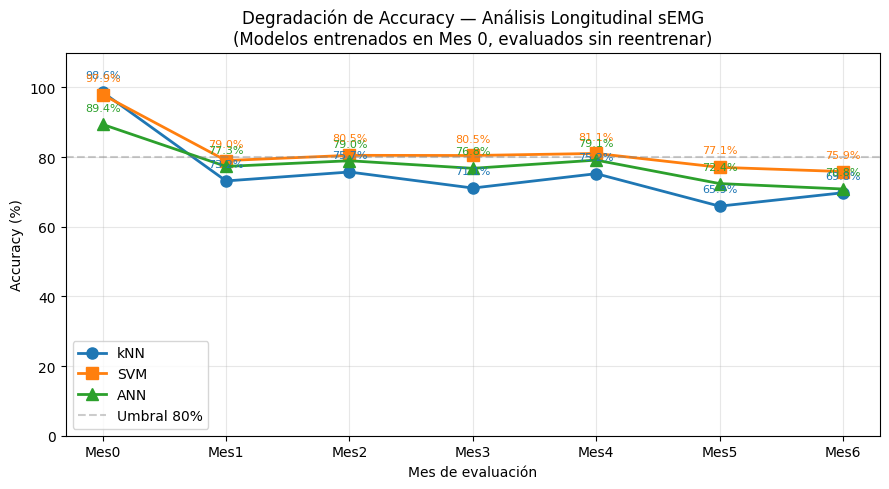

Gráfica guardada: longitudinal_accuracy_plot.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

colors  = {'kNN': '#1f77b4', 'SVM': '#ff7f0e', 'ANN': '#2ca02c'}
markers = {'kNN': 'o',       'SVM': 's',       'ANN': '^'}
x_labels = MESES
x_pos = range(len(MESES))

for model_name in ['kNN', 'SVM', 'ANN']:
    y_vals = [results[model_name][m] * 100 for m in MESES]
    ax.plot(x_pos, y_vals,
            color=colors[model_name],
            marker=markers[model_name],
            label=model_name,
            linewidth=2, markersize=8)
    # Anotar valores
    for xi, yi in zip(x_pos, y_vals):
        ax.annotate(f'{yi:.1f}%', (xi, yi),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8, color=colors[model_name])

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Mes de evaluación')
ax.set_title('Degradación de Accuracy — Análisis Longitudinal sEMG\n'
             '(Modelos entrenados en Mes 0, evaluados sin reentrenar)')
ax.set_ylim(0, 110)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.4, label='Umbral 80%')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'longitudinal_accuracy_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: longitudinal_accuracy_plot.png')

## 6. Reporte detallado por modelo y mes

In [13]:
for mes in MESES:
    X_mes, y_mes = features_by_month[mes]
    X_mes_scaled = scaler.transform(X_mes)
    y_mes_enc    = le.transform(y_mes)

    print(f'\n{"="*60}')
    print(f'MES: {mes}')
    print(f'{"="*60}')

    print('\n[SVM]')
    print(classification_report(y_mes, svm.predict(X_mes), target_names=CLASS_NAMES))

    print('\n[kNN]')
    print(classification_report(y_mes, knn.predict(X_mes), target_names=CLASS_NAMES))

    print('\n[ANN]')
    y_pred_ann = le.inverse_transform(np.argmax(ann.predict(X_mes_scaled, verbose=0), axis=1))
    print(classification_report(y_mes, y_pred_ann, target_names=CLASS_NAMES))


MES: Mes0

[SVM]
              precision    recall  f1-score   support

        fist       0.99      0.99      0.99       950
        open       0.99      0.98      0.98       950
       pinch       0.98      0.99      0.98       950
      waveIn       1.00      1.00      1.00       950
     waveOut       1.00      1.00      1.00       950

    accuracy                           0.99      4750
   macro avg       0.99      0.99      0.99      4750
weighted avg       0.99      0.99      0.99      4750


[kNN]
              precision    recall  f1-score   support

        fist       1.00      1.00      1.00       950
        open       1.00      1.00      1.00       950
       pinch       1.00      1.00      1.00       950
      waveIn       1.00      1.00      1.00       950
     waveOut       1.00      1.00      1.00       950

    accuracy                           1.00      4750
   macro avg       1.00      1.00      1.00      4750
weighted avg       1.00      1.00      1.00      475

In [14]:
# Guardar tabla de resultados
csv_path = MODELS_DIR / 'longitudinal_results.csv'
results_df.to_csv(csv_path)
print(f'Tabla guardada en: {csv_path}')
print()
print((results_df * 100).round(2))

Tabla guardada en: /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann/data/processed/models/longitudinal/longitudinal_results.csv

        kNN    SVM    ANN
Mes0  98.63  97.92  89.39
Mes1  73.16  79.01  77.33
Mes2  75.72  80.51  78.96
Mes3  71.12  80.46  76.78
Mes4  75.24  81.05  79.14
Mes5  65.92  77.07  72.40
Mes6  69.77  75.85  70.84


## 6. Demostración de Reconocimiento (Onset/Offset)
Tal como lo requiere el plan de tesis, un sistema completo HGR no solo debe clasificar qué gesto se está realizando, sino **reconocer** cuándo empieza y termina la actividad muscular. 
El siguiente bloque utiliza la envolvente RMS y un umbral dinámico de ruido para detectar los puntos de **Onset** (inicio) y **Offset** (fin) de un gesto de prueba.

In [ ]:
# ==============================================================================
# DEMOSTRACIÓN DE RECONOCIMIENTO DE ACTIVIDAD (ONSET/OFFSET)
# ==============================================================================
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Asegurar que el modulo src se pueda importar
sys.path.append(os.path.abspath('..'))
from src.activity_detection import plot_onset_offset

# Cargar un archivo de ejemplo (ej. user12, Mes0, gesto fist)
base_path = "../data/longitudinal/usuarios/Mes0/user12/fist.mat"
if not os.path.exists(base_path):
    base_path = "data/longitudinal/usuarios/Mes0/user12/fist.mat"

try:
    raw = scipy.io.loadmat(base_path, simplify_cells=True)
    gesture_data = raw['reps']['fist']['data']
    
    # Manejar variabilidad en la estructura del archivo .mat
    if isinstance(gesture_data, dict):
        gesture_data = [gesture_data]
    elif isinstance(gesture_data, np.ndarray) and len(gesture_data) > 0 and isinstance(gesture_data[0], dict) and 'emg' not in gesture_data[0]:
        pass # Por si la estructura es diferente

    emg_raw = gesture_data[0]['emg'] if 'emg' in gesture_data[0] else gesture_data[0]
    signal = np.array(emg_raw, dtype=np.float32)
    
    # Generar gráfica de Onset/Offset
    print("Analizando la primera repetición del gesto Fist (Usuario 12 - Mes 0)...")
    segments = plot_onset_offset(
        signal=signal,
        gesture_name="Fist (Puño) - Demostración",
        window_size=40,
        noise_samples=100,  # Estimamos ruido base en el primer 0.5 seg
        multiplier=3.0,
        sample_rate=200,
        save_path=None
    )
except Exception as e:
    print(f"Error al cargar o procesar la señal para la demostración: {e}")